In [3]:
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [4]:
import os

file_size = os.path.getsize('5_train.zip') / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")


File size: 8.00 MB


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds

print("Loading Cats vs Dogs dataset safely via TensorFlow...")

# 1. Download and automatically split the dataset (80% Train, 20% Validation)
(train_ds, val_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,  # Automatically creates (image, label) format
    with_info=True
)

# 2. A function to clean, resize, and normalize images
def preprocess_images(image, label):
    image = tf.image.resize(image, (150, 150)) # Resize to 150x150 pixels
    image = image / 255.0                      # Scale pixel values between 0 and 1
    return image, label

# 3. Create optimized data generators for the CNN
BATCH_SIZE = 32

train_generator = (train_ds
                   .map(preprocess_images)
                   .shuffle(1000)
                   .batch(BATCH_SIZE)
                   .prefetch(buffer_size=tf.data.AUTOTUNE))

validation_generator = (val_ds
                        .map(preprocess_images)
                        .batch(BATCH_SIZE)
                        .prefetch(buffer_size=tf.data.AUTOTUNE))

print("Dataset is verified, clean, and ready for model training!")


Loading Cats vs Dogs dataset safely via TensorFlow...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.E1KVHX_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset is verified, clean, and ready for model training!


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Convolutional Layer: Detects simple edges and lines
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Second Convolutional Layer: Detects complex shapes like textures
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Third Convolutional Layer: Detects advanced features like ears or eyes
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flatten the 2D features into a 1D vector for the decision layers
    Flatten(),

    # Fully Connected Layer to interpret features
    Dense(512, activation='relu'),
    Dropout(0.5), # Drops 50% of connections randomly to prevent memorization (overfitting)

    # Final Output Layer: Sigmoid outputs close to 0 (Cat) or 1 (Dog)
    Dense(1, activation='sigmoid')
])

# Compile the model configuration
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print out the layout of your network
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Starting training... This will take a few minutes depending on your hardware.")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)


Starting training... This will take a few minutes depending on your hardware.
Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.6566 - loss: 0.6085 - val_accuracy: 0.7532 - val_loss: 0.5051
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.7660 - loss: 0.4833 - val_accuracy: 0.7644 - val_loss: 0.4994
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8138 - loss: 0.4076 - val_accuracy: 0.8190 - val_loss: 0.4024
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.8571 - loss: 0.3288 - val_accuracy: 0.8235 - val_loss: 0.4172
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8938 - loss: 0.2552 - val_accuracy: 0.8246 - val_loss: 0.4396
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.9311 - loss: 0.1759 - val_accuracy: 0.8244 - val_loss: 0.4969
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.9547 - loss: 0.1198 - val_accuracy: 0.8347 - val_loss: 0.5044
Epoch 8/10
5

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# Add as the first layer in your model, or apply to train_generator:
train_generator = (train_ds
                   .map(preprocess_images)
                   .map(lambda x, y: (data_augmentation(x, training=True), y))
                   .shuffle(1000)
                   .batch(BATCH_SIZE)
                   .prefetch(tf.data.AUTOTUNE))

In [13]:
tf.keras.layers.Dropout(0.5),

(<Dropout name=dropout_2, built=True>,)

In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pretrained weights

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/tmp/ipykernel_552/2011537212.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# Change resize from 150x150 → 224x224
def preprocess_images(image, label):
    image = tf.image.resize(image, (224, 224))  # ← match MobileNetV2's native size
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  # ← use model-specific normalization (scales to [-1, 1])
    return image, label

# Update base_model input_shape to match
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),   # ← now matches exactly, no warning
    include_top=False,
    weights='imagenet'
)

In [17]:
def preprocess_images(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

BATCH_SIZE = 32

train_generator = (train_ds
                   .map(preprocess_images)
                   .map(lambda x, y: (data_augmentation(x, training=True), y))
                   .shuffle(1000)
                   .batch(BATCH_SIZE)
                   .prefetch(tf.data.AUTOTUNE))

validation_generator = (val_ds
                        .map(preprocess_images)
                        .batch(BATCH_SIZE)
                        .prefetch(tf.data.AUTOTUNE))

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pretrained weights

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop]
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 399s 624ms/step - accuracy: 0.8325 - loss: 0.3811 - val_accuracy: 0.9753 - val_loss: 0.1367
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 331s 540ms/step - accuracy: 0.9533 - loss: 0.1468 - val_accuracy: 0.9811 - val_loss: 0.0842
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 329s 537ms/step - accuracy: 0.9630 - loss: 0.1088 - val_accuracy: 0.9852 - val_loss: 0.0653
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 332s 540ms/step - accuracy: 0.9648 - loss: 0.0984 - val_accuracy: 0.9845 - val_loss: 0.0567
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 326s 533ms/step - accuracy: 0.9685 - loss: 0.0892 - val_accuracy: 0.9862 - val_loss: 0.0500
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 385s 537ms/step - accuracy: 0.9674 - loss: 0.0851 - val_accuracy: 0.9867 - val_loss: 0.0464
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 327s 534ms/step - accuracy: 0.9712 - loss: 0.0793 - val_accuracy: 0.9871 - val_loss: 0.0445
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 329s 537ms/step - accuracy: 0.9709 -

In [21]:
# Save your model
model.save('cats_vs_dogs_mobilenetv2.h5')
print("Model saved!")

Model saved!


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


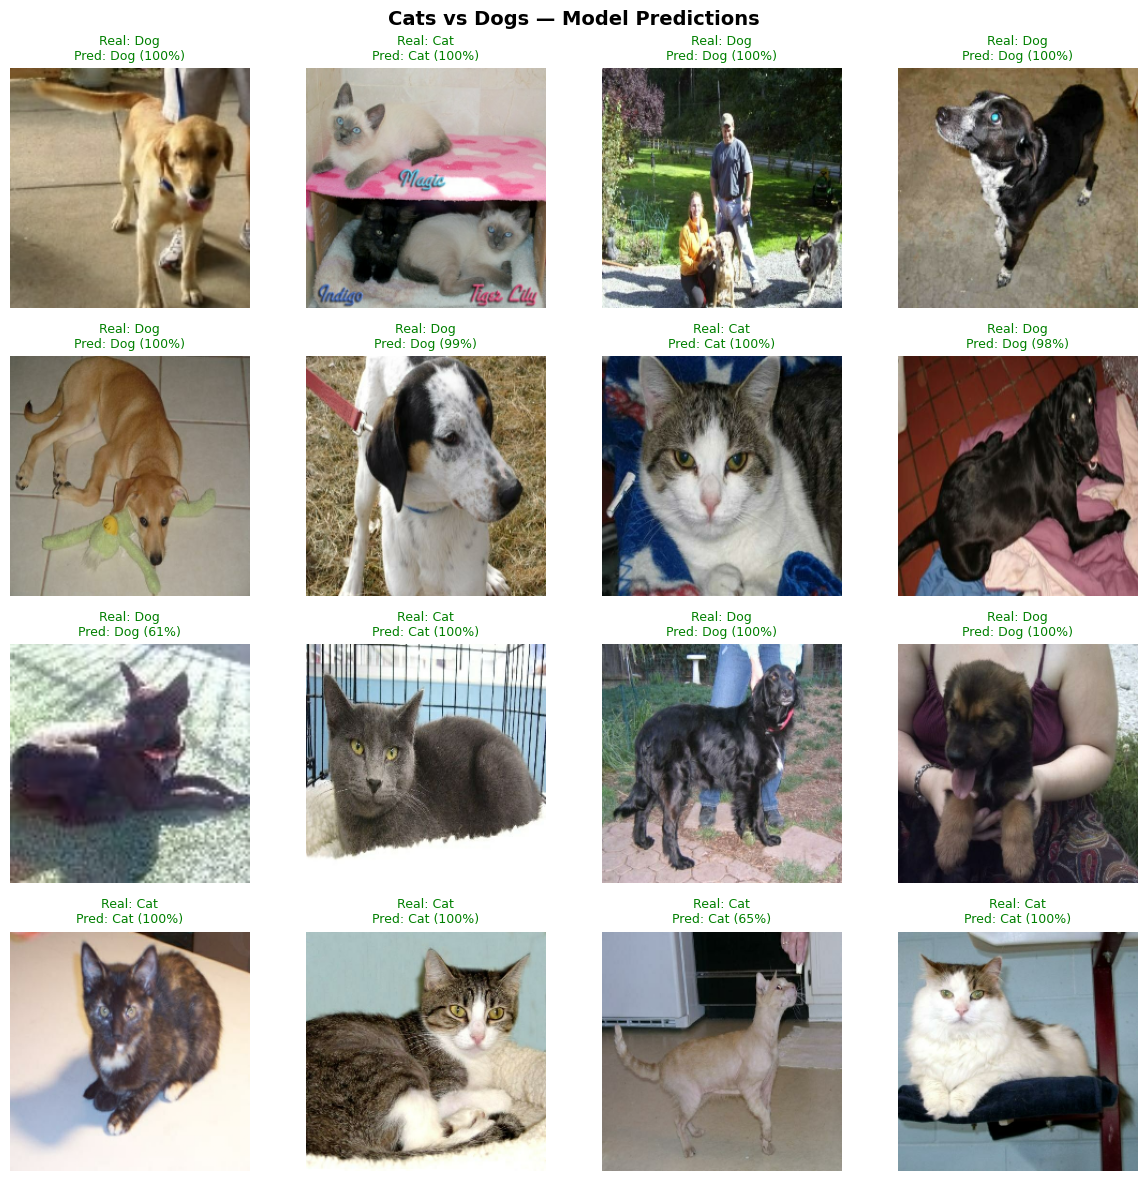

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from validation
for images, labels in validation_generator.take(1):
    predictions = model.predict(images)

# Plot 16 images with predictions
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)

    # Denormalize image for display
    img = images[i].numpy()
    img = (img + 1) / 2.0  # MobileNetV2 was [-1,1], bring back to [0,1]
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    pred = predictions[i][0]
    actual = "Dog" if labels[i] == 1 else "Cat"
    predicted = "Dog" if pred > 0.5 else "Cat"
    confidence = pred if pred > 0.5 else 1 - pred

    # Green title = correct, Red = wrong
    color = "green" if actual == predicted else "red"
    plt.title(f"Real: {actual}\nPred: {predicted} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Cats vs Dogs — Model Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Overall Validation Accuracy: {accuracy:.2%}")
print(f"Overall Validation Loss: {loss:.4f}")

146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9882 - loss: 0.0405
Overall Validation Accuracy: 98.82%
Overall Validation Loss: 0.0405


In [25]:
import os
print(os.listdir('/content/'))

['.config', 'cats_vs_dogs_mobilenetv2.h5', '5_train.zip', 'sample_data']


In [26]:
from google.colab import files
files.download('cats_vs_dogs_mobilenetv2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
